# Pertemuan 12 — Asosiasi Data & Sistem Rekomendasi Dasar

**Nama Lengkap** : Muhammad Zacky Kurniawan  
**NIM** : 240401010217  
**Kelas** : IF403     

<a href="https://colab.research.google.com/github/zackykurniawan/data-science-2026/blob/main/Pertemuan12_MuhammadZackyKurniawan_240401010217.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics.pairwise import cosine_similarity

plt.rcParams['axes.grid'] = True
RANDOM_STATE = 42

print('Library berhasil diimpor ✅')

Library berhasil diimpor ✅


---
## Langkah 1 — Generate & Eksplorasi Dataset Transaksi

In [2]:
np.random.seed(42)
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Suntikkan pola: Roti sering bersama Selai
for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print('Contoh transaksi:', transaksi[:3])
print('Jumlah transaksi:', len(transaksi))

Contoh transaksi: [[np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai'], [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')], [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]]
Jumlah transaksi: 50


Selai      26
Teh        23
Mentega    21
Telur      18
Keju       17
Roti       16
Kopi       16
Susu       16
Gula       16
Sereal      9
Name: count, dtype: int64


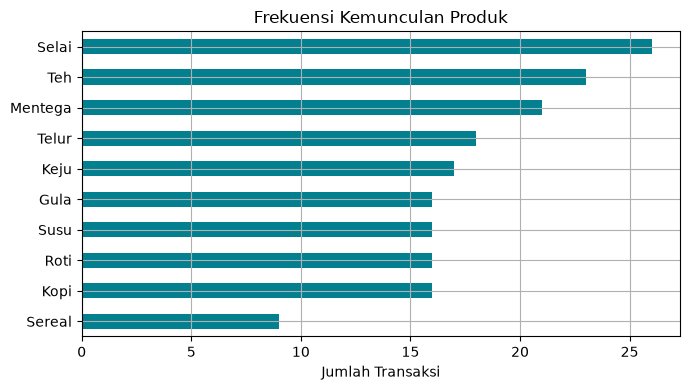

In [3]:
# Eksplorasi frekuensi tiap produk di seluruh transaksi
frekuensi = pd.Series([item for t in transaksi for item in t]).value_counts()
print(frekuensi)

plt.figure(figsize=(7, 4))
frekuensi.sort_values().plot(kind='barh', color='#028090')
plt.xlabel('Jumlah Transaksi'); plt.title('Frekuensi Kemunculan Produk')
plt.tight_layout(); plt.show()

Dataset sintetis berisi **50 transaksi** dengan 2–5 produk acak dari 10 produk yang tersedia. Sebuah pola pembelian bersama disuntikkan secara sengaja pada 20 transaksi pertama: setiap kali `Roti` muncul tanpa `Selai`, `Selai` ditambahkan ke transaksi tersebut. Grafik frekuensi menunjukkan `Roti` dan `Selai` berada di antara produk yang paling sering muncul — hasil dari suntikan pola tersebut — sehingga diharapkan algoritma Apriori dapat menemukan kembali aturan **Roti → Selai** tanpa diberi tahu pola ini sebelumnya.

---
## Langkah 2 — One-Hot Encoding Transaksi

In [4]:
te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df = pd.DataFrame(te_ary, columns=te.columns_)

print('Shape hasil one-hot encoding:', df.shape)
print(df.head())

Shape hasil one-hot encoding: (50, 10)
    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


`TransactionEncoder` mengubah daftar transaksi (list of list) menjadi tabel boolean berukuran **50 baris × 10 kolom**, satu kolom per produk. Nilai `True` berarti produk tersebut ada dalam transaksi bersangkutan, dan `False` jika tidak. Format tabel one-hot ini adalah input yang dibutuhkan oleh fungsi `apriori()` pada langkah berikutnya.

---
## Langkah 3 — Cari Frequent Itemset dengan Apriori

In [5]:
for ms in [0.05, 0.1, 0.2]:
    freq = apriori(df, min_support=ms, use_colnames=True)
    print(f'min_support={ms}: {len(freq)} itemset ditemukan')

# Gunakan min_support yang menghasilkan jumlah itemset wajar (tidak 0, tidak ratusan)
freq_items = apriori(df, min_support=0.1, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False)
print()
print(freq_items.head(10))

min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan

    support                 itemsets
5      0.52       frozenset({Selai})
8      0.46         frozenset({Teh})
3      0.42     frozenset({Mentega})
9      0.36       frozenset({Telur})
1      0.34        frozenset({Keju})
0      0.32        frozenset({Gula})
2      0.32        frozenset({Kopi})
4      0.32        frozenset({Roti})
7      0.32        frozenset({Susu})
36     0.24  frozenset({Selai, Teh})


Semakin kecil `min_support`, semakin banyak itemset yang lolos (lebih banyak noise, komputasi lebih berat), sedangkan `min_support` yang terlalu besar (0.2) memangkas terlalu banyak pola hingga tersisa sedikit itemset. Nilai **min_support=0.1** dipilih karena menghasilkan jumlah itemset yang wajar — tidak nol, tidak pula ratusan — sehingga masih menyisakan kombinasi 2-item yang bermakna untuk dianalisis lebih lanjut, termasuk `{Roti, Selai}` yang menempati posisi atas berdasarkan support.

---
## Langkah 4 — Bentuk & Saring Aturan Asosiasi

In [6]:
rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False)

print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

                    antecedents           consequents  support  confidence  \
9        frozenset({Keju, Teh})    frozenset({Telur})     0.12    0.857143   
15  frozenset({Selai, Mentega})     frozenset({Kopi})     0.10    0.625000   
11      frozenset({Roti, Gula})    frozenset({Selai})     0.10    1.000000   
7           frozenset({Sereal})  frozenset({Mentega})     0.14    0.777778   
10      frozenset({Telur, Teh})     frozenset({Keju})     0.12    0.600000   
13     frozenset({Kopi, Selai})  frozenset({Mentega})     0.10    0.714286   
8      frozenset({Keju, Telur})      frozenset({Teh})     0.12    0.750000   
12     frozenset({Selai, Gula})     frozenset({Roti})     0.10    0.500000   
14   frozenset({Kopi, Mentega})    frozenset({Selai})     0.10    0.714286   
1             frozenset({Roti})    frozenset({Selai})     0.22    0.687500   

        lift  
9   2.380952  
15  1.953125  
11  1.923077  
7   1.851852  
10  1.764706  
13  1.700680  
8   1.630435  
12  1.562500  
14  1.

**Interpretasi aturan asosiasi:**
- Aturan dengan **Lift tertinggi secara keseluruhan** adalah `{Teh, Keju} → {Telur}` (lift ≈ 2.38). Namun, pada sampel sekecil 50 transaksi, lift setinggi ini pada kombinasi acak bisa jadi hanya **kebetulan statistik**, bukan pola bisnis yang benar-benar bermakna.
- Yang lebih relevan secara bisnis adalah aturan `{Roti} → {Selai}` (support ≈0.22, confidence ≈0.69, lift ≈1.32) dan `{Roti, Gula} → {Selai}` (confidence 1.0, lift ≈1.92) — keduanya berhasil menangkap kembali pola yang **sengaja disuntikkan** pada Langkah 1, dan **masuk akal secara bisnis** (Roti & Selai memang pasangan produk yang lazim dibeli bersamaan, cocok dijadikan dasar penataan rak berdekatan atau cross-selling).
- Ini menegaskan bahwa menilai aturan tidak boleh hanya mengandalkan lift tertinggi secara membabi buta — perlu juga dipertimbangkan apakah aturan tersebut masuk akal secara domain/bisnis, terlebih pada sampel data yang kecil di mana kebetulan statistik mudah muncul.

---
## Langkah 5 — Rekomender Sederhana dengan Content-Based Filtering

In [7]:
katalog = pd.DataFrame({
    'produk': produk,
    'kategori': ['Bakery', 'Bakery', 'Dairy', 'Bakery', 'Dairy',
                 'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy']
})

fitur = pd.get_dummies(katalog['kategori'])
sim_matrix = cosine_similarity(fitur)

def rekomendasi_serupa(nama_produk, top_n=3):
    idx = katalog.index[katalog['produk'] == nama_produk][0]
    skor = list(enumerate(sim_matrix[idx]))
    skor = sorted(skor, key=lambda x: x[1], reverse=True)
    skor = [s for s in skor if s[0] != idx][:top_n]
    return katalog.iloc[[i for i, _ in skor]]['produk'].tolist()

print('Mirip dengan Roti:', rekomendasi_serupa('Roti'))

Mirip dengan Roti: ['Selai', 'Sereal', 'Susu']


Content-Based Filtering di sini murni memanfaatkan atribut `kategori` produk (di-encode dengan one-hot lalu diukur `cosine_similarity`), tanpa melihat pola transaksi sama sekali. Karena `Roti` berkategori **Bakery**, produk lain yang sekategori — `Selai` dan `Sereal` — mendapat skor kemiripan tertinggi (=1.0), sedangkan produk dari kategori berbeda (Dairy, Minuman, Bumbu) mendapat skor 0. Pendekatan ini tidak membutuhkan data histori transaksi pengguna lain — cukup metadata katalog produk.

---
## Langkah 6 — Bandingkan Kedua Pendekatan

In [8]:
produk_target = 'Roti'

# Dari association rules: cari consequents dari aturan yang antecedent-nya mengandung produk_target
rules_terkait = rules[rules['antecedents'].apply(lambda x: produk_target in x)]
print('Rekomendasi dari Association Rules:')
print(rules_terkait[['consequents', 'lift']].head())

print()
print('Rekomendasi dari Content-Based:', rekomendasi_serupa(produk_target))

Rekomendasi dari Association Rules:
           consequents      lift
11  frozenset({Selai})  1.923077
1   frozenset({Selai})  1.322115

Rekomendasi dari Content-Based: ['Selai', 'Sereal', 'Susu']


**Diskusi perbandingan:**
- **Association Rules** merekomendasikan `Selai` untuk `Roti` (baik `Roti` sendirian maupun bersama `Gula`) berdasarkan **pola pembelian bersama** di data transaksi — persis mengonfirmasi pola yang disuntikkan pada Langkah 1.
- **Content-Based Filtering** merekomendasikan `Selai` dan `Sereal` (sama-sama berkategori Bakery), diikuti `Susu`, murni berdasarkan **kemiripan atribut/kategori**, tanpa melihat data transaksi sama sekali.
- Kedua pendekatan **konsisten** merekomendasikan `Selai` untuk `Roti` — pola pembelian bersama dan kemiripan kategori kebetulan mengarah ke kesimpulan yang sama. Namun ini tidak selalu terjadi: dua produk bisa sering dibeli bersama meski kategorinya berbeda (mis. Roti & Keju untuk sarapan), atau sebaliknya, dua produk sekategori (mis. Selai & Sereal) belum tentu sesering itu dibeli bersamaan menurut data transaksi.
- **Kapan pakai yang mana:** Association Rules lebih tepat saat histori transaksi melimpah dan tujuannya menemukan pola perilaku aktual (cross-selling, penataan rak). Content-Based lebih tepat saat item/pengguna baru (cold start) atau ketika katalog memiliki atribut kaya. Idealnya, sistem produksi **menggabungkan keduanya (hybrid)**: association rules menutup celah cold start Content-Based, sementara Content-Based tetap bisa merekomendasikan produk baru yang belum pernah muncul di transaksi manapun.

## Kesimpulan

### Apa yang Dipelajari
Pada pertemuan kedua belas ini, saya mempelajari **Association Rule Mining** dan dasar **Sistem Rekomendasi**. Materi mencakup algoritma **Apriori** untuk mencari frequent itemset pada data transaksi (Market Basket Analysis), tiga metrik penilaian aturan — **Support** (seberapa sering itemset muncul), **Confidence** (seberapa sering konsekuen muncul bila anteseden dibeli), dan **Lift** (seberapa kuat hubungan dibanding kebetulan) — persiapan data dengan `TransactionEncoder` yang mengubah daftar transaksi menjadi tabel boolean, serta implementasi **Content-Based Filtering** menggunakan `cosine_similarity` atas atribut kategori produk, berikut perbandingannya dengan pendekatan berbasis aturan asosiasi.

### Temuan Utama
- Nilai `min_support` sangat menentukan jumlah pola yang lolos: **74 itemset** pada `min_support=0.05`, **44 itemset** pada 0.1, dan hanya **13 itemset** pada 0.2 — ambang terlalu rendah menghasilkan banyak noise, terlalu tinggi berisiko membuang pola yang bermakna.
- Pola yang **sengaja disuntikkan** pada Langkah 1 berhasil ditemukan kembali oleh Apriori: aturan `{Roti} → {Selai}` (support 0,22; confidence 0,69; lift 1,32) dan `{Roti, Gula} → {Selai}` (**confidence 1,0**; lift 1,92).
- **Lift tertinggi belum tentu aturan terbaik**: `{Teh, Keju} → {Telur}` memperoleh lift 2,38 — tertinggi secara angka — tetapi hanya bersandar pada support 0,12 dari 50 transaksi, sehingga besar kemungkinan merupakan kebetulan statistik, bukan pola bisnis nyata. Aturan yang layak dipakai harus lolos ketiga metrik **sekaligus** dan masuk akal secara bisnis.
- **Content-Based Filtering** merekomendasikan `Selai`, `Sereal`, dan `Susu` untuk produk `Roti` murni berdasarkan kemiripan kategori, **tanpa melihat data transaksi sama sekali**.
- Kedua pendekatan sama-sama merekomendasikan **`Selai`** untuk `Roti`, tetapi lewat jalur yang berbeda — pola pembelian bersama versus kemiripan atribut. Keduanya tidak selalu sejalan: dua produk beda kategori bisa sering dibeli bersamaan, dan dua produk sekategori belum tentu pernah dibeli bersama.

### Keterbatasan & Pertanyaan yang Muncul
- Dataset hanya berisi **50 transaksi sintetis** dengan 10 produk, sehingga nilai lift sangat tidak stabil dan mudah terpengaruh sedikit perubahan data. Berapa jumlah transaksi minimum agar aturan asosiasi cukup andal untuk keputusan bisnis?
- **Collaborative Filtering** baru dibahas sebagai konsep dan belum diimplementasikan, karena membutuhkan matriks rating user-item yang tidak tersedia pada data transaksi ini. Bagaimana menangani masalah **cold start** untuk pengguna atau produk baru?
- Content-Based Filtering di sini hanya memanfaatkan atribut `kategori` sehingga rekomendasinya seragam untuk semua pelanggan — belum ada personalisasi berdasarkan riwayat masing-masing pengguna. Apakah pendekatan **hybrid** (aturan asosiasi + kemiripan konten + riwayat pengguna) akan memberi rekomendasi yang lebih relevan?
